1. Load data

In [1]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path.cwd()        
DATA_DIR = BASE_DIR.parent / "data"

path = DATA_DIR / "clarified_dataset.xlsx"
print("Файл существует:", path.exists())
print("Полный путь:", path)

df = pd.read_excel(path)
df.shape

Файл существует: True
Полный путь: /Users/artemsehovcov/Desktop/Volgu/ML/breast-temp-reconstruction/data/clarified_dataset.xlsx


(9162, 194)

2. EDA

In [2]:
df.columns[:30]

Index(['Unnamed: 0', 'protocol_id', 'patient_id', 'suffix',
       'measurement_number', 'total_measurements', 'last_measurements',
       'sitting_position', 'unc_th_cls', 'th_cls', 'year', 'month', 'day',
       'doctor', 'birthday_year', 'birthday_month', 'birthday_day',
       'diagnosis_secondary', 'own_doctor', 'air_temperature',
       'place_of_examination', 'sensor_type', 'anamnesis', 'note',
       'clinic_description', 'examinations', 'diagnosis_main', 'control_year',
       'control_month', 'control_day'],
      dtype='object')

In [3]:
df.head()

,Unnamed: 0,protocol_id,patient_id,suffix,measurement_number,total_measurements,last_measurements,sitting_position,unc_th_cls,th_cls,...,MG059,MG060,MG061,MG062,ocls,split_col,th_known,breast_id,year_calc,clarified
0,58,0002AA04795A,0002AA04795,A,1,1,True,0,0,0,...,-0.37,-0.07,0.8,1.5,0,0_0_2_0,True,0002AA04795A_r,34.0,0
1,66,0002AA04804A,0002AA04804,A,1,2,False,0,5,5,...,-1.07,0.03,1.1,1.4,1,5_2_2_0,True,0002AA04804A_r,57.0,0
2,67,0002AA04805A,0002AA04805,A,1,1,True,0,0,0,...,-0.61,0.59,1.0,0.8,0,0_1_3_0,True,0002AA04805A_r,36.0,0
3,68,0002AA04806A,0002AA04806,A,1,10,False,0,0,0,...,-0.29,0.31,0.5,0.6,0,0_1_2_0,True,0002AA04806A_r,35.0,0
4,72,0002AA03578B,0002AA03578,B,1,3,False,0,0,0,...,-0.59,0.11,0.5,0.6,0,0_0_2_0,True,0002AA03578B_r,32.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9162 entries, 0 to 9161
Columns: 194 entries, Unnamed: 0 to clarified
dtypes: bool(2), float64(114), int64(42), object(36)
memory usage: 13.4+ MB


In [5]:
df.isna().sum().sort_values(ascending=False).head(20)


t_norm,vn                        9162
body_temperature                 9159
outlying                         9156
histology                        9154
age                              9137
diagnosis_th_text_in_brackets    8753
own_doctor                       8488
extended_sum                     7942
super_code                       7942
heredity                         7927
dp                               7782
hormone                          7577
city                             7090
city_code_address                7085
further_treatment                6361
day_code                         6236
ultrasound                       5346
diagnosis_secondary              5205
examinations                     4326
cycle_float                      3498
dtype: int64

3. Define X/y

In [6]:
TARGET = "clarified"
y = df[TARGET]
X = df.drop(columns=[TARGET])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9162, 193)
y shape: (9162,)


4. Target analysis

In [7]:
TARGET = "clarified"

# Базовые вещи: тип, пропуски, сколько уникальных значений
print("TARGET dtype:", df[TARGET].dtype)
print("Missing in TARGET:", df[TARGET].isna().sum())
print("Unique values in TARGET:", df[TARGET].nunique())

# Уникальные значения
print("Unique values list:", df[TARGET].dropna().unique()[:20])

# Распределение классов (частоты)
vc = df[TARGET].value_counts(dropna=False)
print("\nValue counts:\n", vc)

# Распределение в процентах
vcp = df[TARGET].value_counts(normalize=True, dropna=False) * 100
print("\nValue counts %:\n", vcp.round(2))


# Быстрая проверка баланса (для бинарного таргета)
if df[TARGET].nunique(dropna=True) == 2:
    majority = vcp.max()
    print(f"\nMajority class share: {majority:.2f}%")


TARGET dtype: int64
Missing in TARGET: 0
Unique values in TARGET: 2
Unique values list: [0 1]

Value counts:
 clarified
0    9068
1      94
Name: count, dtype: int64

Value counts %:
 clarified
0    98.97
1     1.03
Name: proportion, dtype: float64

Majority class share: 98.97%


4.1 Target cleaning & fixation (y)

In [8]:
TARGET = "clarified" 

assert TARGET in df.columns, f"Target column '{TARGET}' not found in df.columns"

y = df[TARGET]

assert y.isna().sum() == 0, "Target contains NaN (пропуски в y недопустимы)"
assert y.nunique(dropna=True) == 2, f"Target is not binary. Unique: {y.dropna().unique()}"

y = y.astype("int64")

# Страховка 
actual_classes = set(y.unique().tolist()) 
assert actual_classes.issubset({0, 1}), f"Unexpected target classes: {actual_classes}"

vc_abs = y.value_counts(dropna=False)  
vc_pct = (y.value_counts(normalize=True, dropna=False) * 100).round(2) 

print("y prepared:", y.shape, "| dtype:", y.dtype)
print("\nClass distribution (abs):\n", vc_abs)
print("\nClass distribution (%):\n", vc_pct)
print(f"\nMajority class share: {float(vc_pct.max()):.2f}%")


y prepared: (9162,) | dtype: int64

Class distribution (abs):
 clarified
0    9068
1      94
Name: count, dtype: int64

Class distribution (%):
 clarified
0    98.97
1     1.03
Name: proportion, dtype: float64

Majority class share: 98.97%


4.2 Feature matrix (X) definition

In [9]:

X = df.drop(columns=[TARGET]) 

# Таргета в X быть не должно
assert TARGET not in X.columns, "Target column is still in X (data leakage risk)"

# Проверяем согласованность размеров
assert len(X) == len(y), f"X and y length mismatch: len(X)={len(X)}, len(y)={len(y)}"

print("X prepared:", X.shape)

X prepared: (9162, 193)


5. Feature types

In [10]:
# Числовые признаки (непрерывные и дискретные)
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

# Категориальные признаки (строки + bool)
cat_cols = X.select_dtypes(include=["object", "bool"]).columns

print("Numerical features:", len(num_cols))
print("Categorical features:", len(cat_cols))

Numerical features: 155
Categorical features: 38


5.1. Potential ID columns

In [11]:
id_like_cols = [
    col for col in X.columns
    if "id" in col.lower()
]
id_like_cols

['protocol_id', 'patient_id', 'breast_id']

5.2 Leakage checks / columns to drop

In [12]:
import numpy as np

# Список кандидатов на удаление
cols_to_drop = list(id_like_cols)
print("ID-like cols:", cols_to_drop)

# Проверка: сколько уникальных значений в этих колонках
n_rows = len(X)

for col in cols_to_drop:
    nunique = X[col].nunique(dropna=False)
    share = nunique / n_rows * 100 
    print(f"{col}: unique={nunique} ({share:.2f}% of rows)")
    
# Проверка на константные столбцы
const_cols = [col for col in X.columns if X[col].nunique(dropna=False) <= 1]
print("\nConstant columns count:", len(const_cols))
print("Examples:", const_cols[:20])

# Проверка на почти уникальные признаки
almost_id_cols = []
for col in X.columns:
    nunique = X[col].nunique(dropna=False)
    if nunique / n_rows >= 0.99:
        almost_id_cols.append(col)

print("\nAlmost-ID columns (>=99% unique):", len(almost_id_cols))
print("Examples:", almost_id_cols[:20])


final_drop_cols = sorted(set(cols_to_drop))
print("\nFinal drop cols:", final_drop_cols)

X_clean = X.drop(columns=final_drop_cols)

print("\nX_clean shape:", X_clean.shape)
print("Dropped columns:", len(final_drop_cols))

        

ID-like cols: ['protocol_id', 'patient_id', 'breast_id']
protocol_id: unique=5688 (62.08% of rows)
patient_id: unique=3613 (39.43% of rows)
breast_id: unique=9162 (100.00% of rows)

Constant columns count: 5
Examples: ['sitting_position', 'sensor_type', 'addition_type', 'RTM_skin', 't_norm,vn']

Almost-ID columns (>=99% unique): 2
Examples: ['Unnamed: 0', 'breast_id']

Final drop cols: ['breast_id', 'patient_id', 'protocol_id']

X_clean shape: (9162, 190)
Dropped columns: 3


5.3 Missing values strategy для X_clean.

5.3.1 Missing values (Пропуски) в X_clean

In [13]:
na_cnt = X_clean.isna().sum()
na_pct = na_cnt / len(X_clean) * 100 

na_table = (
    pd.DataFrame({"na_cnt": na_cnt, "na_pct": na_pct})
      .query("na_cnt > 0")
      .sort_values("na_cnt", ascending=False)
)

print("Columns with missing:", na_table.shape[0] )
na_table.head(20)

Columns with missing: 37


,na_cnt,na_pct
"t_norm,vn",9162,100.000000
body_temperature,9159,99.967256
outlying,9156,99.934512
histology,9154,99.912683
age,9137,99.727134
diagnosis_th_text_in_brackets,8753,95.535909
own_doctor,8488,92.643528
extended_sum,7942,86.684130
super_code,7942,86.684130
heredity,7927,86.520410


5.3.2 Types of columns with missing values(Типы данных)

In [14]:
cols_with_na = na_table.index.tolist()
X_clean[cols_with_na].dtypes.value_counts()

object     21
float64    16
Name: count, dtype: int64

5.3.3 Decide drop vs impute by missing rate(удаление и заполнение)

In [15]:
DROP_NA_PCT = 60.0
drop_na_cols = na_table[na_table["na_pct"] > DROP_NA_PCT].index.tolist()

# столбцы, которые имее смысл заполнить
impute_cols = na_table[na_table["na_pct"] <= DROP_NA_PCT].index.tolist()

print("Drop cols (Много NaN):", len(drop_na_cols))
print("Impute cols:", len(impute_cols))

drop_na_cols[:20], impute_cols[:20]


Drop cols (Много NaN): 16
Impute cols: 21


(['t_norm,vn',
  'body_temperature',
  'outlying',
  'histology',
  'age',
  'diagnosis_th_text_in_brackets',
  'own_doctor',
  'extended_sum',
  'super_code',
  'heredity',
  'dp',
  'hormone',
  'city',
  'city_code_address',
  'further_treatment',
  'day_code'],
 ['ultrasound',
  'diagnosis_secondary',
  'examinations',
  'cycle_day',
  'cycle_float',
  'clinic_description',
  'first_pregnancy_result',
  'first_pregnancy_age',
  'control_day',
  'control_month',
  'control_year',
  'tf_vn',
  'year_calc',
  'air_temperature',
  't_norm,k',
  'tf_koj',
  'birth_count',
  'preg_count',
  'unc_th_cls',
  'figure'])

5.3.4 Split impute columns by type(Числовые и категориальные столбцы)

In [16]:
num_impute_cols = X_clean[impute_cols].select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_impute_cols = X_clean[impute_cols].select_dtypes(include=["object", "bool"]).columns.tolist()

print("Numerical to impute:", len(num_impute_cols))
print("Categorical/bool to impute:", len(cat_impute_cols))

Numerical to impute: 7
Categorical/bool to impute: 14


5.3.5 Make data great again (Сделать данные пригодными прямо сейчас)

In [17]:
# Первичный клининг
X_intermediate_removal = X_clean.drop(columns=drop_na_cols).copy()

# Числовые признаки - заполнение NaN медианой 
for col in num_impute_cols:
    if col in X_intermediate_removal.columns:
        X_intermediate_removal[col] = X_intermediate_removal[col].fillna(X_intermediate_removal[col].median())

# Категориальные/булевы
for col in cat_impute_cols:
    if col in  X_intermediate_removal.columns:
        if X_intermediate_removal[col].dtype == "bool":
            X_intermediate_removal[col] = X_intermediate_removal[col].fillna(False)
        else:
            X_intermediate_removal[col] = X_intermediate_removal[col].fillna("Unknown")

print("X_b4 shape:", X_intermediate_removal.shape)
print("Missing after:", int(X_intermediate_removal.isna().sum().sum()))

X_b4 shape: (9162, 174)
Missing after: 0


5.4 Encoding категориальных признаков (и финальная матрица X_final)

In [18]:
X_ready = X_intermediate_removal.copy()

# bool -> int
bool_cols = X_ready.select_dtypes(include="bool").columns.tolist()
for col in bool_cols:
    X_ready[col] = X_ready[col].astype("int8")

# 2) object -> one-hot
cat_cols = X_ready.select_dtypes(include=["object"]).columns.tolist()
X_final = pd.get_dummies(X_ready, columns=cat_cols, dummy_na=False)

print("X_ready shape:", X_ready.shape)
print("X_final shape:", X_final.shape)
print("All numeric in X_final:", all(pd.api.types.is_numeric_dtype(X_final[c]) for c in X_final.columns))

X_ready shape: (9162, 174)
X_final shape: (9162, 31945)
All numeric in X_final: True


In [ ]:
# 6.1 Define columns, filter healthy subset, build features (X) and targets (Y)

import numpy as np
import pandas as pd

MW_COLS = [f"mw_{i}" for i in range(10)]   # глубинные (MW / RTM)
IR_COLS = [f"ir_{i}" for i in range(10)]   # кожные (IR)

missing_cols = [c for c in (MW_COLS + IR_COLS + ["th_cls"]) if c not in df.columns]
print("Missing required columns:", missing_cols)

# Берём только здоровые записи (Th0)
df_ml = df.copy()
df_ml = df_ml[df_ml["th_cls"] == 0].copy()

# Если хотите ещё "только известные" (в некоторых базах th_known бывает True/False):
if "th_known" in df_ml.columns:
    df_ml = df_ml[df_ml["th_known"] == True].copy()

print("Healthy subset shape:", df_ml.shape)

df_ml = df_ml.dropna(subset=IR_COLS + MW_COLS).copy()
print("After dropna(IR+MW):", df_ml.shape)

# Базовые признаки = 10 кожных температур
X_base = df_ml[IR_COLS].astype(float).copy()

# Доп. признаки (агрегаты по кожному полю)
ir_values = X_base.values
X_base["ir_mean"] = ir_values.mean(axis=1)
X_base["ir_std"]  = ir_values.std(axis=1)
X_base["ir_min"]  = ir_values.min(axis=1)
X_base["ir_max"]  = ir_values.max(axis=1)
X_base["ir_range"] = X_base["ir_max"] - X_base["ir_min"]

# "анизотропия"/контраст: отклонение от среднего по точкам
for i in range(10):
    X_base[f"ir_dev_{i}"] = X_base[f"ir_{i}"] - X_base["ir_mean"]

X = X_base
Y = df_ml[MW_COLS].astype(float).copy()

print("X shape:", X.shape, "Y shape:", Y.shape)
X.head()

Missing required columns: []
Healthy subset shape: (5726, 194)
After dropna(IR+MW): (5726, 194)
X shape: (5726, 25) Y shape: (5726, 10)


,ir_0,ir_1,ir_2,ir_3,ir_4,ir_5,ir_6,ir_7,ir_8,ir_9,...,ir_dev_0,ir_dev_1,ir_dev_2,ir_dev_3,ir_dev_4,ir_dev_5,ir_dev_6,ir_dev_7,ir_dev_8,ir_dev_9
0,33.0,33.4,32.7,33.4,32.6,32.9,32.8,32.7,33.0,34.1,...,-0.06,0.34,-0.36,0.34,-0.46,-0.16,-0.26,-0.36,-0.06,1.04
2,34.5,34.2,33.9,33.8,33.7,34.0,33.1,34.0,34.5,33.0,...,0.63,0.33,0.03,-0.07,-0.17,0.13,-0.77,0.13,0.63,-0.87
3,34.3,34.0,34.3,33.9,33.4,33.3,33.0,32.8,33.4,32.9,...,0.77,0.47,0.77,0.37,-0.13,-0.23,-0.53,-0.73,-0.13,-0.63
4,35.3,35.1,34.9,35.1,34.8,34.8,34.4,34.3,34.4,33.9,...,0.60,0.40,0.20,0.40,0.10,0.10,-0.30,-0.40,-0.30,-0.80
5,32.6,34.0,34.2,33.4,33.1,32.5,32.6,32.7,33.6,32.5,...,-0.52,0.88,1.08,0.28,-0.02,-0.62,-0.52,-0.42,0.48,-0.62


In [20]:
# 6.2 Train/test split + baseline LinearRegression (with scaling) + MAE report

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

baseline.fit(X_train, y_train)
pred = baseline.predict(X_test)

mae_total = mean_absolute_error(y_test, pred)  # sklearn умеет multioutput average='uniform_average' по умолчанию
mae_by_point = mean_absolute_error(y_test, pred, multioutput="raw_values")

print("Baseline (LinearRegression) MAE total:", round(float(mae_total), 4))
print("MAE by point:", np.round(mae_by_point, 4))

# удобная табличка
mae_table = pd.DataFrame({
    "point": MW_COLS,
    "MAE": mae_by_point
}).sort_values("MAE", ascending=False)

mae_table

Baseline (LinearRegression) MAE total: 0.3768
MAE by point: [0.4824 0.3809 0.3595 0.3659 0.3557 0.3603 0.3551 0.3633 0.378  0.3667]


,point,MAE
0,mw_0,0.482365
1,mw_1,0.380941
8,mw_8,0.377958
9,mw_9,0.366682
3,mw_3,0.365857
7,mw_7,0.363306
5,mw_5,0.360251
2,mw_2,0.359513
4,mw_4,0.355734
6,mw_6,0.355051


In [ ]:
# 6.3 Try several stronger models (still fast) and compare MAE

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor

models = {}

# Ridge часто лучше "голой" линейки на шумных данных
models["Ridge(alpha=1.0)"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=42))
])

models["Ridge(alpha=10.0)"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0, random_state=42))
])

# kNN иногда хорошо работает, если зависимости "локальные"
models["KNN(k=15)"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=15, weights="distance"))
])

# Деревья/ансамбли (обычно дают прирост по точности)
models["RandomForest"] = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    max_depth=None,
    min_samples_leaf=2
)

models["ExtraTrees"] = ExtraTreesRegressor(
    n_estimators=600,
    random_state=42,
    n_jobs=-1,
    max_depth=None,
    min_samples_leaf=2
)

results = []
pred_store = {}

for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    p = mdl.predict(X_test)
    mae = mean_absolute_error(y_test, p)
    results.append((name, float(mae)))
    pred_store[name] = p

res_df = pd.DataFrame(results, columns=["model", "MAE_total"]).sort_values("MAE_total")
res_df

,model,MAE_total
2,KNN(k=15),0.374317
0,Ridge(alpha=1.0),0.376768
1,Ridge(alpha=10.0),0.376784
4,ExtraTrees,0.376859
3,RandomForest,0.379562


Best model: KNN(k=15)
MAE total: 0.3743
MAE by point: [0.4527 0.3855 0.3566 0.3687 0.3596 0.3589 0.3542 0.3566 0.369  0.3814]


,point,MAE
0,mw_0,0.452674
1,mw_1,0.385541
9,mw_9,0.381418
8,mw_8,0.369034
3,mw_3,0.368660
4,mw_4,0.359584
5,mw_5,0.358896
7,mw_7,0.356605
2,mw_2,0.356583
6,mw_6,0.354172


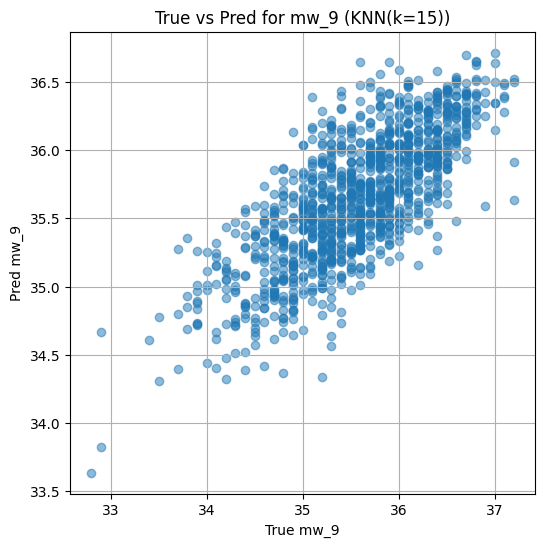


Sample #1 | mean abs err: 0.114
true: [35.4 35.3 34.7 35.4 34.9 34.7 34.7 35.2 35.7 35.7]
pred: [35.29 35.15 34.82 35.17 35.06 34.76 34.76 35.21 35.51 35.75]
err : [0.11 0.15 0.12 0.23 0.16 0.06 0.06 0.01 0.19 0.05]

Sample #2 | mean abs err: 0.356
true: [34.4 35.1 35.3 35.7 35.3 35.5 33.1 34.  34.5 35.9]
pred: [34.77 35.27 35.33 35.35 35.37 35.12 34.05 34.68 34.85 35.69]
err : [0.37 0.17 0.03 0.35 0.07 0.38 0.95 0.68 0.35 0.21]

Sample #3 | mean abs err: 0.388
true: [35.5 36.  35.8 36.5 35.9 36.4 36.4 35.5 36.1 36.3]
pred: [35.07 35.73 35.8  35.72 35.52 35.68 35.65 35.59 35.67 36.28]
err : [0.43 0.27 0.   0.78 0.38 0.72 0.75 0.09 0.43 0.02]

Sample #4 | mean abs err: 0.465
true: [35.2 35.4 35.4 35.5 35.  34.9 35.  34.9 35.2 35.5]
pred: [35.51 35.79 35.58 35.59 35.65 35.61 35.57 35.58 35.68 36.09]
err : [0.31 0.39 0.18 0.09 0.65 0.71 0.57 0.68 0.48 0.59]

Sample #5 | mean abs err: 0.130
true: [35.8 36.  36.3 36.1 36.2 36.1 35.8 35.9 35.8 36.7]
pred: [35.63 35.97 36.09 35.97 35.85 36.0

In [ ]:
# 6.4 

import matplotlib.pyplot as plt

best_name = res_df.iloc[0]["model"]
best_pred = pred_store[best_name]

mae_total = mean_absolute_error(y_test, best_pred)
mae_by_point = mean_absolute_error(y_test, best_pred, multioutput="raw_values")

print("Best model:", best_name)
print("MAE total:", round(float(mae_total), 4))
print("MAE by point:", np.round(mae_by_point, 4))

best_mae_table = pd.DataFrame({
    "point": MW_COLS,
    "MAE": mae_by_point
}).sort_values("MAE", ascending=False)

display(best_mae_table)


point_idx = 9
y_true_1 = y_test.iloc[:, point_idx].values
y_pred_1 = best_pred[:, point_idx]

plt.figure(figsize=(6, 6))
plt.scatter(y_true_1, y_pred_1, alpha=0.5)
plt.xlabel(f"True {MW_COLS[point_idx]}")
plt.ylabel(f"Pred {MW_COLS[point_idx]}")
plt.title(f"True vs Pred for {MW_COLS[point_idx]} ({best_name})")
plt.grid(True)
plt.show()

rng = np.random.RandomState(42)
idxs = rng.choice(len(y_test), size=min(5, len(y_test)), replace=False)

for k, idx in enumerate(idxs, 1):
    true_row = y_test.iloc[idx].values
    pred_row = best_pred[idx]
    abs_err = np.abs(true_row - pred_row)

    print(f"\nSample #{k} | mean abs err: {abs_err.mean():.3f}")
    print("true:", np.round(true_row, 2))
    print("pred:", np.round(pred_row, 2))
    print("err :", np.round(abs_err, 2))

MAE по точке: mw_6 ≈ 0.354°C
Mean abs err по 5 тест-примерам
min: 0.114°C
max: 0.465°C
среднее по этим 5: (0.114+0.356+0.388+0.465+0.130)/5 = 0.291°C